In [ ]:
!pip install ultralytics roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="mBeemtNCzqYZj2MRDcGy")
project = rf.workspace("nivu").project("indian-license-plate-knte7")
version = project.version(1)
dataset = version.download("yolov8")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.3 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...


In [ ]:
import os
print(os.listdir('/content/Indian-License-Plate-1'))

['train', 'data.yaml', 'valid', 'test', 'README.dataset.txt', 'README.roboflow.txt']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))

GPU available: True
GPU name: Tesla T4


In [ ]:
import os

dataset_path = '/content/Indian-License-Plate-1'

print(os.listdir(dataset_path))

['train', 'data.yaml', 'valid', 'test', 'README.dataset.txt', 'README.roboflow.txt']


In [ ]:
from ultralytics import YOLO


model = YOLO('yolov8n.pt')

# Train
model.train(
    data=f'{dataset_path}/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='license_plate_detector',
    patience=10,
    save=True,
    plots=True
)

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Indian-License-Plate-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=license_plate_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ove

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x780f36a1d9d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

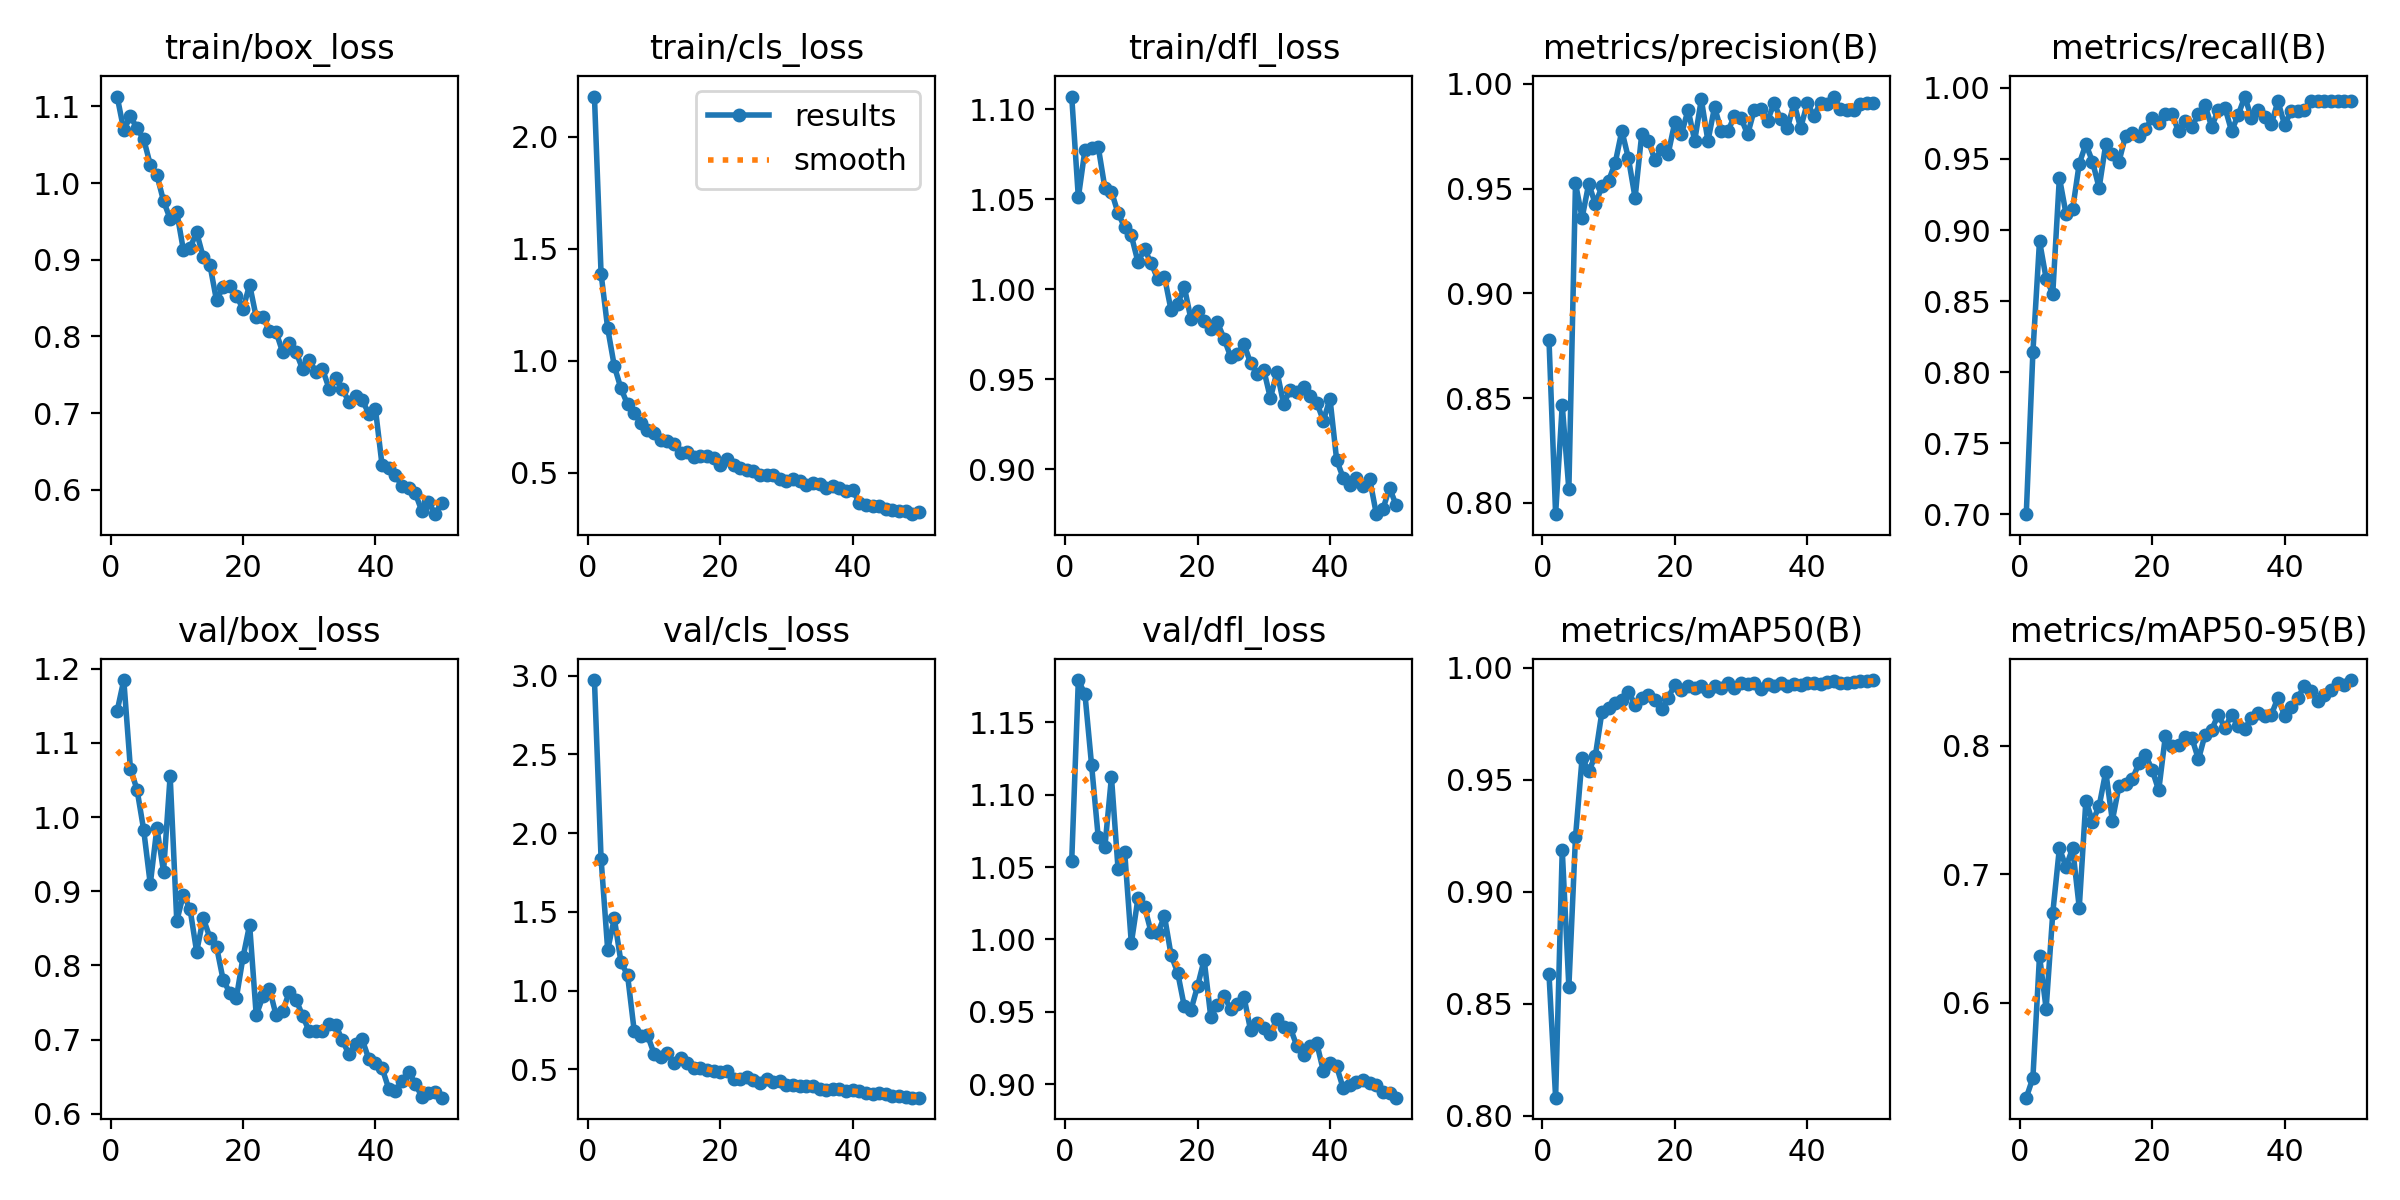

In [ ]:
# Show training graphs
from IPython.display import Image
Image('/content/runs/detect/license_plate_detector/results.png')

In [ ]:
training_metrics = model.val(split='train')
validation_metrics = model.val(split='val')
test_metrics = model.val(split='test')

def show_metrics(name, metrics):
    print(f"\n{name}")
    print(f"mAP@50      : {metrics.box.map50:.4f}")
    print(f"mAP@50-95   : {metrics.box.map:.4f}")
    print(f"Precision   : {metrics.box.mp:.4f}")
    print(f"Recall      : {metrics.box.mr:.4f}")

show_metrics("Train", training_metrics)
show_metrics("Validation", validation_metrics)
show_metrics("Test", test_metrics)

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1244.6±377.0 MB/s, size: 24.3 KB)
val: Scanning /content/Indian-License-Plate-1/train/labels.cache... 1156 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1156/1156 440.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 73/73 5.9it/s 12.4s
                   all       1156       1149      0.993      0.997      0.994      0.883
Speed: 1.5ms preprocess, 3.6ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val-4
Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1109.7±415.2 MB/s, size: 25.7 KB)
val: Scanning /content/Indian-License-Plate-1/valid/labels.cache... 330 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 330/330 153.8Mit/s 0.0s
                 Class  

In [ ]:
# Load best trained model
trained_model = YOLO('/content/runs/detect/license_plate_detector/weights/best.pt')

# Convert to TFLite
trained_model.export(format='tflite', imgsz=640)

print("TFLite conversion done!")

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/license_plate_detector/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 385ms
Prepared 4 packages in 2.05s
Installed 4 packages in 266ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...


Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 5.2s, saved as '/content/runs/detect/license_plate_detector/weights/best.onnx' (11.8 MB)
requirements: Ultralytics requirement ['onnx2tf>=1.26.3,<1.29.0'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 1 package in 111ms
Prepared 1 package in 68ms
Installed 1 package in 4ms
 + onnx2tf==1.28.8

requirements: AutoUpdate success ✅ 0.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

requirements: Ultralytics requirements ['tf_keras<=2.19.0', 'sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 45 packages in 4.56s
Prepared 8 packages in 36.78s
Uninstalled 3 packages in 1.21s
Installed 8 packages in 381ms
 + ai-edge-litert==2.1.5
 + backports-strenum==1.3.1
 + onnx-graphsurgeon==0.6.1
 + onnxruntime-gpu==1.26.0
 + sng4onnx==2.0.